<a href="https://colab.research.google.com/github/DksMh/data-mining/blob/main/02_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1 — 라이브러리 + 데이터 로드
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/데이터마이닝/analysis_ready.csv',
                 index_col=0, parse_dates=True)

print(f'✅ 데이터 로드: {df.shape}')
print(df.columns.tolist())

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Mounted at /content/drive
✅ 데이터 로드: (223, 11)
['KODEX_반도체_ret', 'TIGER_200IT_ret', 'SOXX_KRW_ret', 'QQQ_KRW_ret', 'USDKRW_ret', 'SP500_ret', 'KOSPI_ret', 'VIX_ret', 'WTI_ret', 'AI_interest', 'phase']


In [2]:
# STEP 2 — OLS 다중회귀분석 (H1-1 ~ H1-4 가설 검증)
import statsmodels.api as sm

X_COLS = ['USDKRW_ret','SP500_ret','KOSPI_ret','VIX_ret','WTI_ret','AI_interest']
X = sm.add_constant(df[X_COLS])

TARGETS = {
    'KODEX_반도체': 'KODEX_반도체_ret',
    'TIGER_200IT':  'TIGER_200IT_ret',
    'SOXX_KRW':     'SOXX_KRW_ret',
    'QQQ_KRW':      'QQQ_KRW_ret',
}

results = {}
for name, col in TARGETS.items():
    model = sm.OLS(df[col], X).fit()
    results[name] = model
    print(f'\n{"="*50}')
    print(f'  {name} — OLS 결과')
    print(f'{"="*50}')
    print(f'Adj. R²: {model.rsquared_adj:.4f}')
    print(f'관측치:  {model.nobs:.0f}')
    print(model.summary().tables[1])


  KODEX_반도체 — OLS 결과
Adj. R²: 0.5736
관측치:  223
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0024      0.003     -0.695      0.488      -0.009       0.004
USDKRW_ret     -0.0875      0.183     -0.478      0.633      -0.448       0.273
SP500_ret       0.1955      0.134      1.463      0.145      -0.068       0.459
KOSPI_ret       1.1563      0.090     12.813      0.000       0.978       1.334
VIX_ret         0.0104      0.019      0.534      0.594      -0.028       0.049
WTI_ret         0.0906      0.036      2.539      0.012       0.020       0.161
AI_interest     0.0001    9.4e-05      1.168      0.244   -7.54e-05       0.000

  TIGER_200IT — OLS 결과
Adj. R²: 0.3655
관측치:  223
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0017

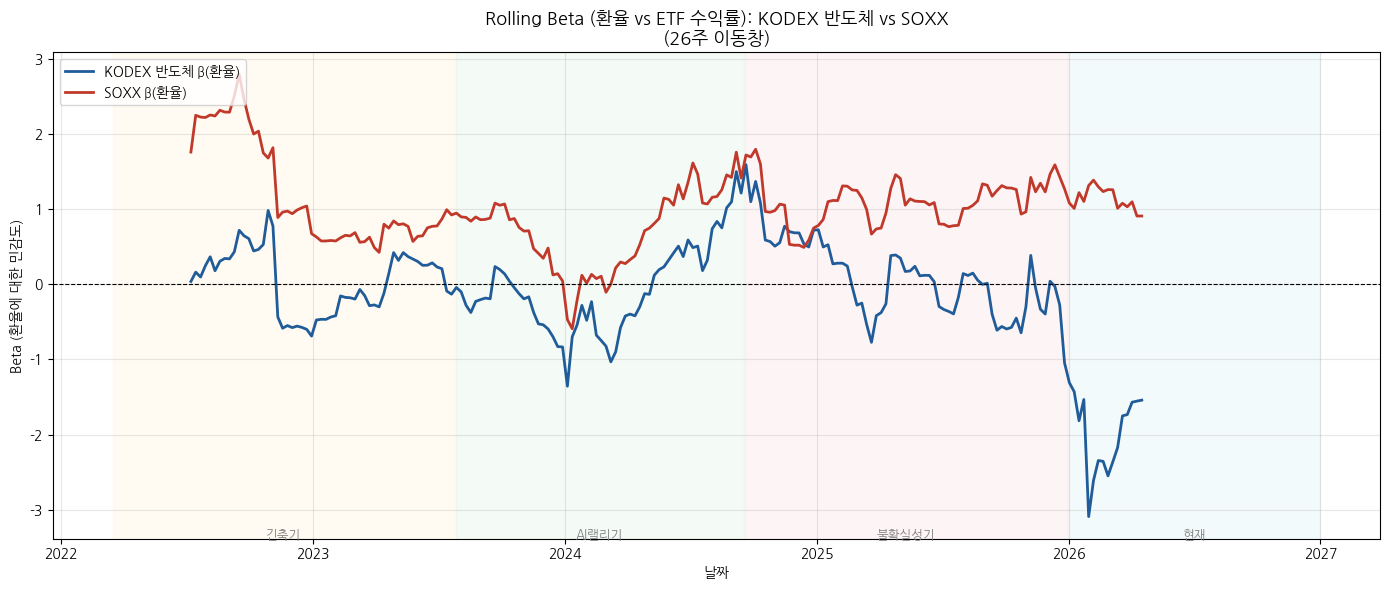

✅ Rolling Beta 차트 저장 완료


In [3]:
# Rolling Beta — KODEX 반도체 vs SOXX (환율 기준)
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm

WINDOW = 26  # 26주 = 약 6개월

X_COLS = ['USDKRW_ret','SP500_ret','KOSPI_ret','VIX_ret','WTI_ret','AI_interest']
X = sm.add_constant(df[X_COLS])

# 국면 배경색
PHASES = {
    '긴축기':     ('2022-03-17', '2023-07-26', '#FFF3CD'),
    'AI랠리기':   ('2023-07-27', '2024-09-17', '#D4EDDA'),
    '불확실성기': ('2024-09-18', '2025-12-31', '#F8D7DA'),
    '현재':       ('2026-01-01', '2026-12-31', '#D1ECF1'),
}

fig, ax = plt.subplots(figsize=(14, 6))

# KODEX 반도체 Rolling Beta (환율)
rols_kodex = RollingOLS(df['KODEX_반도체_ret'], X, window=WINDOW).fit()
beta_kodex = rols_kodex.params['USDKRW_ret']

# SOXX Rolling Beta (환율)
rols_soxx = RollingOLS(df['SOXX_KRW_ret'], X, window=WINDOW).fit()
beta_soxx = rols_soxx.params['USDKRW_ret']

# 국면 배경
for phase, (start, end, color) in PHASES.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=color, label=f'_{phase}')

# Beta 라인
ax.plot(beta_kodex.index, beta_kodex,
        color='#1F5C99', lw=2, label='KODEX 반도체 β(환율)')
ax.plot(beta_soxx.index, beta_soxx,
        color='#C0392B', lw=2, label='SOXX β(환율)')

ax.axhline(0, color='black', lw=0.8, linestyle='--')

# 국면 라벨
for phase, (start, end, color) in PHASES.items():
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else -3,
            phase, ha='center', fontsize=9, color='gray')

ax.set_title('Rolling Beta (환율 vs ETF 수익률): KODEX 반도체 vs SOXX\n(26주 이동창)', fontsize=13)
ax.set_xlabel('날짜')
ax.set_ylabel('Beta (환율에 대한 민감도)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/rolling_beta_USDKRW.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Rolling Beta 차트 저장 완료')

In [4]:
# 기술통계량
desc = df.describe().T[['count','mean','std','min','50%','max']]
desc.columns = ['관측치수','평균','표준편차','최솟값','중앙값','최댓값']
desc = desc.round(4)

print("=== 기술통계량 ===")
print(desc.to_string())
desc.to_csv('/content/drive/MyDrive/데이터마이닝/descriptive_stats.csv', encoding='utf-8-sig')
print('✅ 기술통계량 저장 완료')

=== 기술통계량 ===
                  관측치수       평균     표준편차     최솟값      중앙값       최댓값
KODEX_반도체_ret    223.0   0.0059   0.0462 -0.1131   0.0031    0.2216
TIGER_200IT_ret  223.0  -0.0014   0.0363 -0.1123  -0.0027    0.1945
SOXX_KRW_ret     223.0   0.0060   0.0449 -0.1710   0.0035    0.1221
QQQ_KRW_ret      223.0   0.0039   0.0289 -0.1042   0.0061    0.0822
USDKRW_ret       223.0   0.0010   0.0125 -0.0522   0.0006    0.0329
SP500_ret        223.0   0.0022   0.0235 -0.0908   0.0031    0.0658
KOSPI_ret        223.0   0.0037   0.0278 -0.1056   0.0031    0.0896
VIX_ret          223.0   0.0104   0.1564 -0.3172  -0.0084    1.0928
WTI_ret          223.0   0.0018   0.0570 -0.1342   0.0028    0.3563
AI_interest      223.0  31.2735  22.7174  5.0000  27.0000  100.0000
✅ 기술통계량 저장 완료


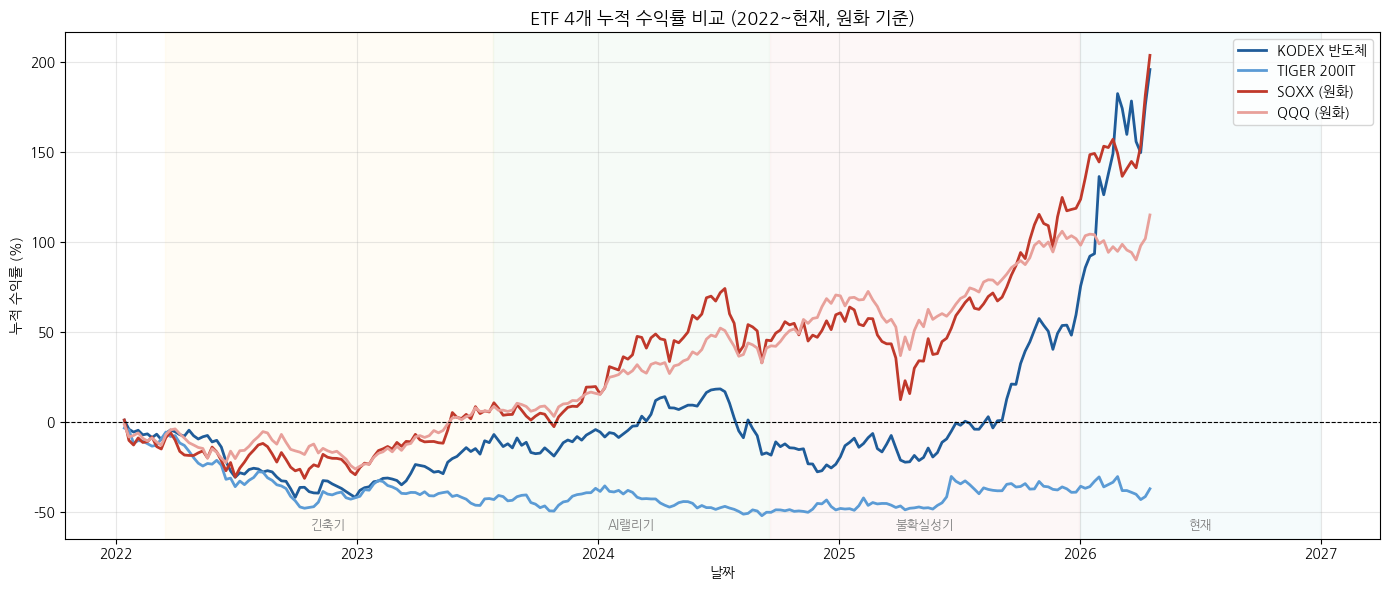

✅ 누적 수익률 저장 완료


In [5]:
# 누적 수익률 차트
fig, ax = plt.subplots(figsize=(14, 6))

etf_cols = {
    'KODEX 반도체': 'KODEX_반도체_ret',
    'TIGER 200IT':  'TIGER_200IT_ret',
    'SOXX (원화)':  'SOXX_KRW_ret',
    'QQQ (원화)':   'QQQ_KRW_ret',
}
colors = ['#1F5C99','#5B9BD5','#C0392B','#E8A09A']

for (name, col), color in zip(etf_cols.items(), colors):
    cumret = (1 + df[col]).cumprod() - 1
    ax.plot(cumret.index, cumret * 100, label=name, color=color, lw=2)

PHASES = {
    '긴축기':     ('2022-03-17','2023-07-26','#FFF3CD'),
    'AI랠리기':   ('2023-07-27','2024-09-17','#D4EDDA'),
    '불확실성기': ('2024-09-18','2025-12-31','#F8D7DA'),
    '현재':       ('2026-01-01','2026-12-31','#D1ECF1'),
}
for phase, (s, e, c) in PHASES.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.2, color=c)
    mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
    ax.text(mid, 0.02, phase,
            transform=ax.get_xaxis_transform(),
            ha='center', fontsize=9, color='gray')

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('ETF 4개 누적 수익률 비교 (2022~현재, 원화 기준)', fontsize=13)
ax.set_xlabel('날짜')
ax.set_ylabel('누적 수익률 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 누적 수익률 저장 완료')

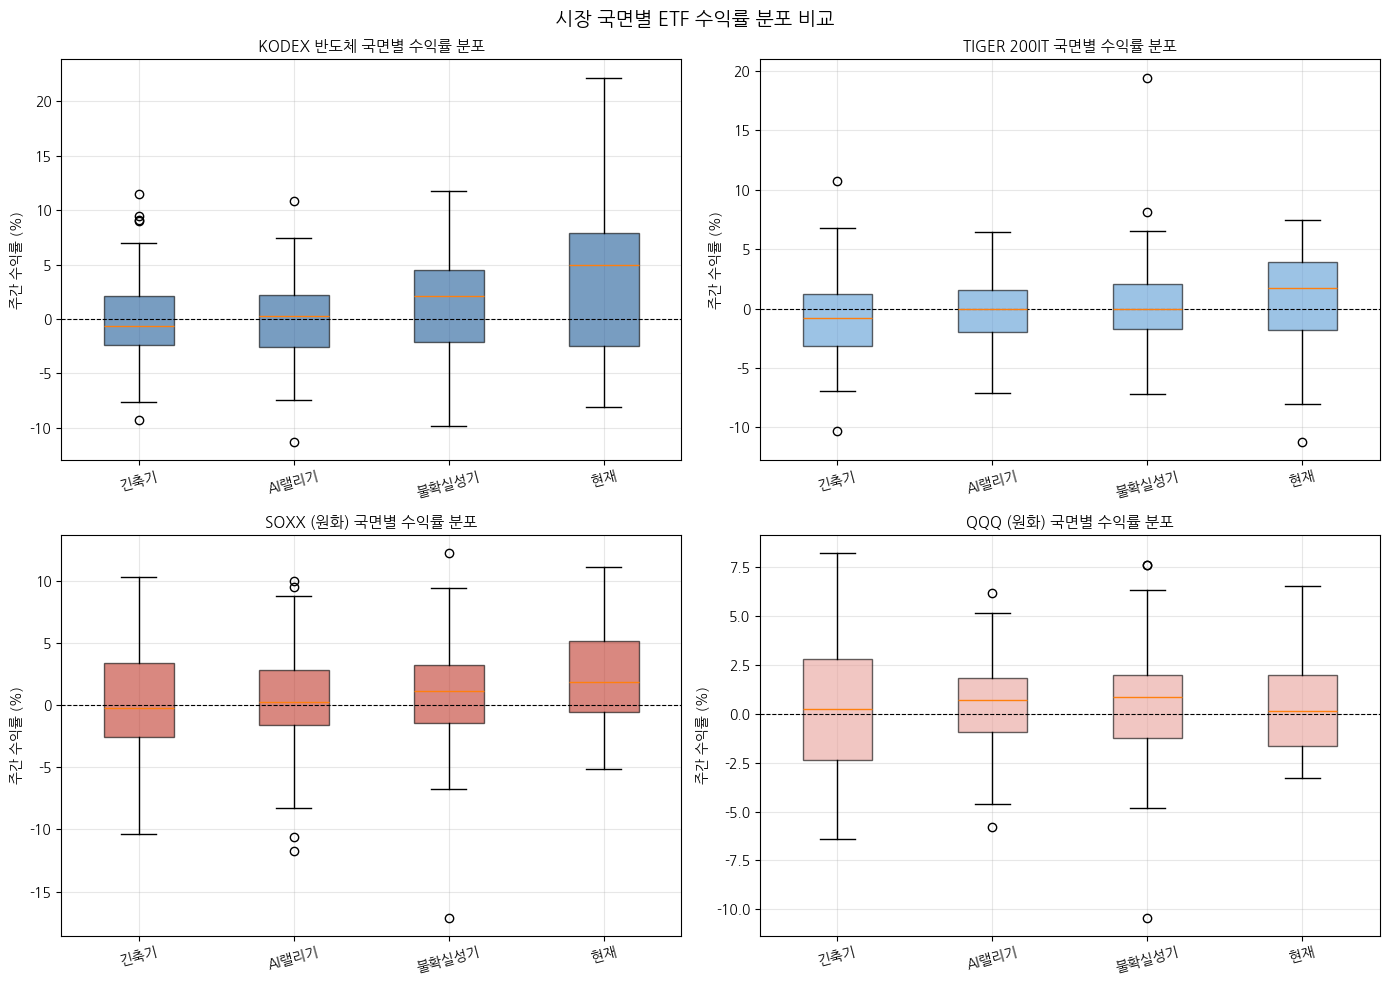

✅ Boxplot 저장 완료


In [6]:
# 국면별 Boxplot (기타 제외, 4개 ETF 전체)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

etf_list = [
    ('KODEX 반도체', 'KODEX_반도체_ret', '#1F5C99'),
    ('TIGER 200IT',  'TIGER_200IT_ret',  '#5B9BD5'),
    ('SOXX (원화)',  'SOXX_KRW_ret',     '#C0392B'),
    ('QQQ (원화)',   'QQQ_KRW_ret',      '#E8A09A'),
]

# 기타 제외
phase_order = ['긴축기','AI랠리기','불확실성기','현재']
df_plot = df[df['phase'] != '기타']

for ax, (name, col, color) in zip(axes.flatten(), etf_list):
    data = [df_plot[df_plot['phase']==p][col].dropna() * 100
            for p in phase_order]
    bp = ax.boxplot(data, labels=phase_order, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'{name} 국면별 수익률 분포', fontsize=11)
    ax.set_ylabel('주간 수익률 (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('시장 국면별 ETF 수익률 분포 비교', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/boxplot_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplot 저장 완료')

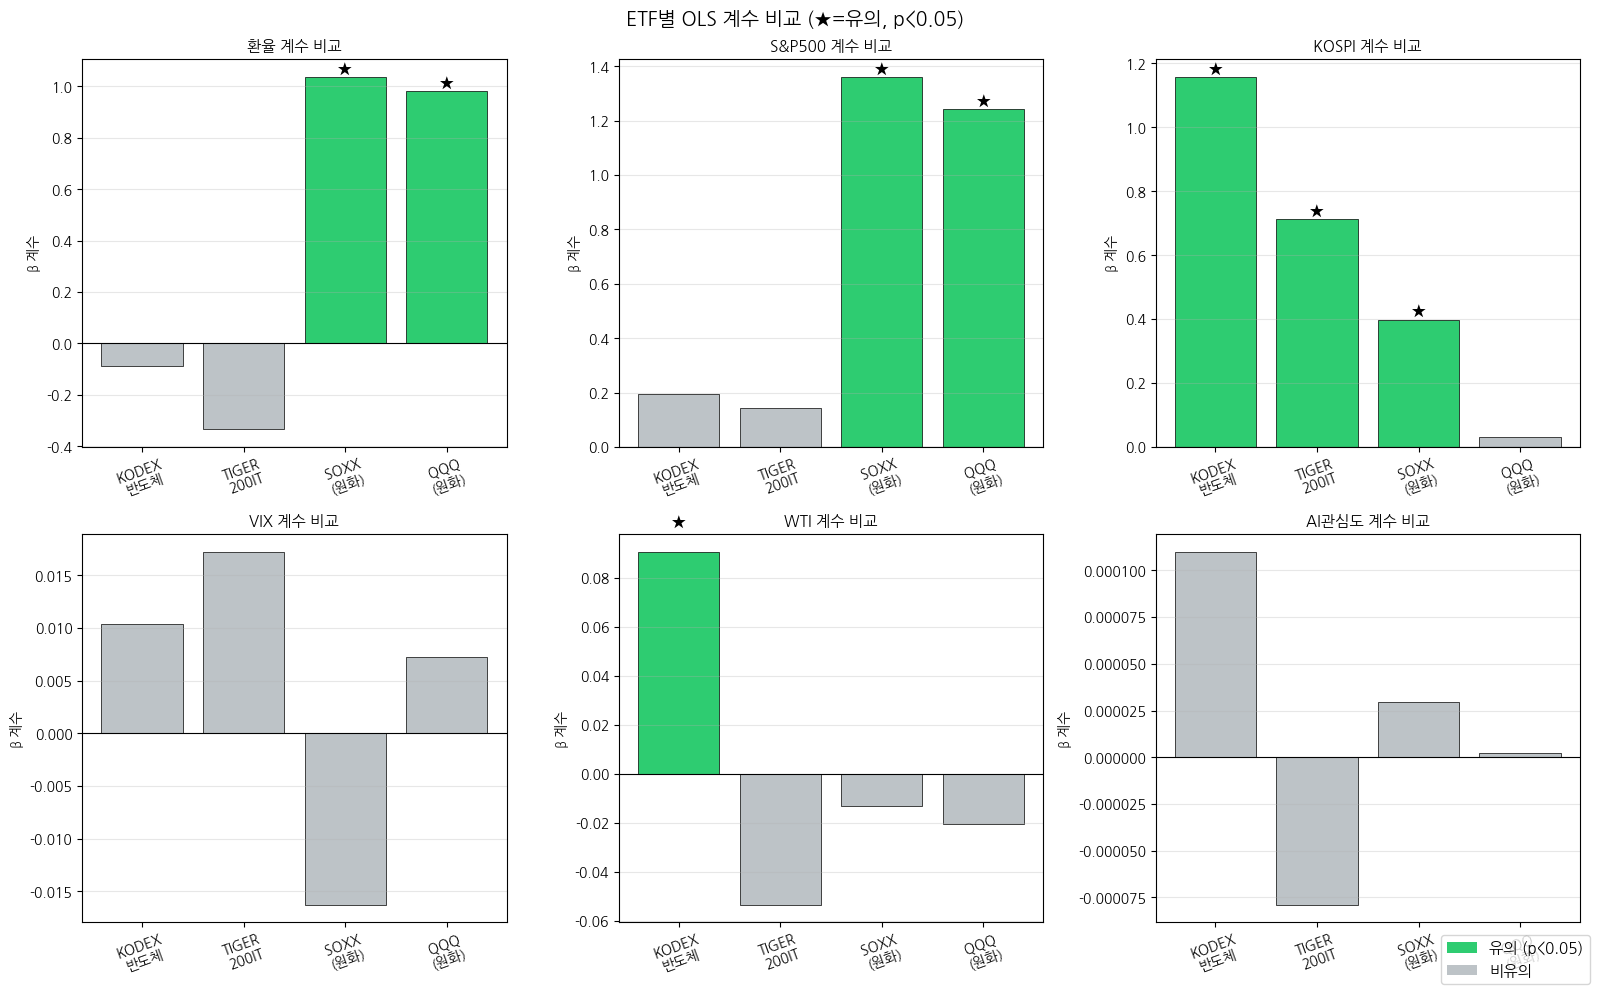

✅ OLS 계수 비교 저장 완료


In [7]:
# OLS 계수 비교 (results 재사용, 6개 변수 전체)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

variables  = ['USDKRW_ret','SP500_ret','KOSPI_ret','VIX_ret','WTI_ret','AI_interest']
var_labels = ['환율','S&P500','KOSPI','VIX','WTI','AI관심도']
etf_names  = ['KODEX_반도체','TIGER_200IT','SOXX_KRW','QQQ_KRW']
etf_labels = ['KODEX\n반도체', 'TIGER\n200IT', 'SOXX\n(원화)', 'QQQ\n(원화)']

x = range(len(etf_names))

for ax, var, label in zip(axes.flatten(), variables, var_labels):
    coefs  = [results[e].params[var] for e in etf_names]
    pvals  = [results[e].pvalues[var] for e in etf_names]
    colors = ['#2ECC71' if p < 0.05 else '#BDC3C7' for p in pvals]

    # bar 그릴 때
    bars = ax.bar(etf_labels, coefs, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} 계수 비교', fontsize=11)
    ax.set_ylabel('β 계수')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

    for bar, p in zip(bars, pvals):
        if p < 0.05:
            ypos = bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.05
            ax.text(bar.get_x() + bar.get_width()/2, ypos,
                    '★', ha='center', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ECC71', label='유의 (p<0.05)'),
    Patch(facecolor='#BDC3C7', label='비유의')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=11)
plt.suptitle('ETF별 OLS 계수 비교 (★=유의, p<0.05)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/ols_coef_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ OLS 계수 비교 저장 완료')